In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

plt.style.use("ggplot")

# random traces prob should remove these
trace = "9bc86d6cd1ee254aaa313492f0fd88be8bd7b92d50d4237ff52d7685440c0906"
t2 = "734272c01926d19690e5ec308bab64ef97950b75b1c7582283e0783fce1751d8"

# trace with the highest number of invocations
t_max = "155e47f8e7f751d0c845049456d01832013c61336a8cd85901330ac821a71534"

df = pd.read_csv(
    "data/AzureFunctionsInvocationTraceForTwoWeeksJan2021.txt"
)


#df["end_timestamp"] = pd.to_timedelta(df["end_timestamp"], unit="seconds")
df["start_timestamp"] = df["end_timestamp"] - df["duration"]
df

,app,func,end_timestamp,duration,start_timestamp
0,7b2c43a2bc30f6bb438074df88b603d2cb982d3e7961de...,e3cdb48830f66eb8689cc0223514569a69812b77e6611e...,7.949090e-02,0.078,1.490900e-03
1,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,337cd24a7d5fd5c92460faee4ebe6a186a0eb322bd17b7...,5.715786e+01,57.154,3.860041e-03
2,1573b95c039e51cc012b543a4af3bc7c3ee9485acbb003...,48cc770d590d3c5a7691b3b4e9302f82ec3be5ddc2a037...,5.913048e+01,59.125,5.477905e-03
3,f274d71de386ccc77e4ca74766dbc485461c3053059d47...,3d2aee54a133509f16fb636d74128c2adcfcac71c6dcef...,6.252541e+00,6.236,1.654107e-02
4,7b2c43a2bc30f6bb438074df88b603d2cb982d3e7961de...,68bbfd828223a505d7917339f4656c5f33ff93225cdb9d...,6.682396e-02,0.050,1.682396e-02
...,...,...,...,...,...
1980946,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,1.209597e+06,0.001,1.209597e+06
1980947,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,1.209598e+06,0.001,1.209598e+06
1980948,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,1.209599e+06,0.001,1.209599e+06
1980949,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,1.209599e+06,0.001,1.209599e+06


## Statistics on Az2021

In [18]:

df["duration"].describe()

count    1.980951e+06
mean     3.347944e+00
std      1.850717e+01
min      0.000000e+00
25%      1.000000e-03
50%      3.100000e-02
75%      3.720000e-01
max      5.786200e+02
Name: duration, dtype: float64

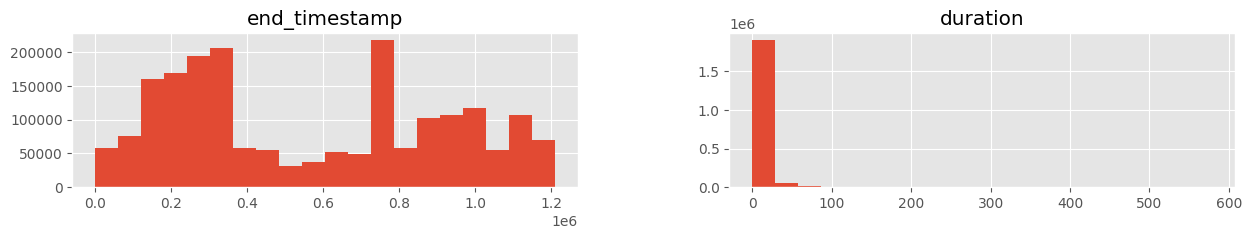

In [19]:
df.hist(column=["end_timestamp", "duration"], layout=[1, 2], figsize=[15, 2], bins=20)
plt.show()

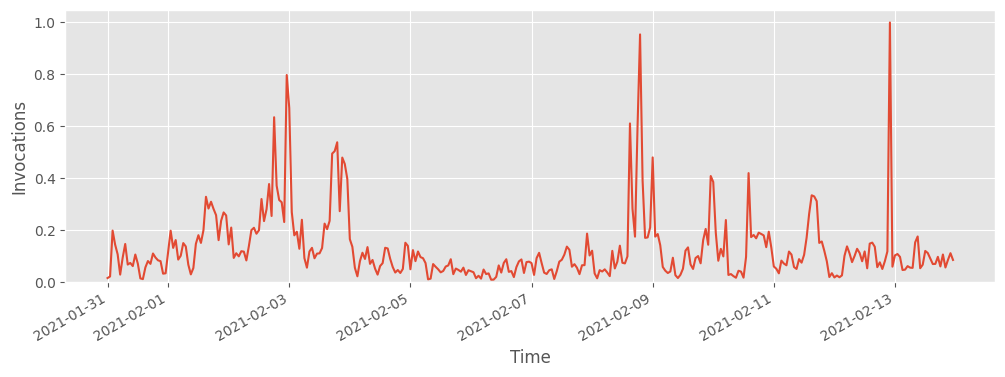

In [20]:
hourly = (
    df.assign(datetime=pd.to_datetime(df["end_timestamp"], origin="2021-01-31", unit="s"))
    .set_index("datetime")
    .resample("h")
    .size()
)
hourly_norm = hourly / hourly.max()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly_norm.index, hourly_norm.values)
ax.set_xlabel("Time")
ax.set_ylabel("Invocations")
ax.set_ylim(0, 1.05)
#ax.set_title("Azure Functions 2021 — hourly invocations (normalized)")
fig.autofmt_xdate()
plt.show()

# Duration distribution

Left: empirical CDF of all invocation durations. Right: for each application, mean / max / P95 / P99 duration; each curve is the CDF of that statistic across applications.

In [21]:
def get_cdf(df, field):
    vals = sorted(df[field].values)
    invs = 100.0 * np.arange(0, len(df)) / len(df)
    return vals, invs

In [22]:
def plt_cdf(df, field="duration", title="Duration"):
    
    df_tokens, df_inv = get_cdf(df, field)
    plt.plot(df_tokens, df_inv)
    plt.title(title)
    plt.ylabel("CDF (%)")
    plt.xlabel("Duration (s)")
    plt.xscale("log")
    plt.grid(visible=True)
    plt.show()

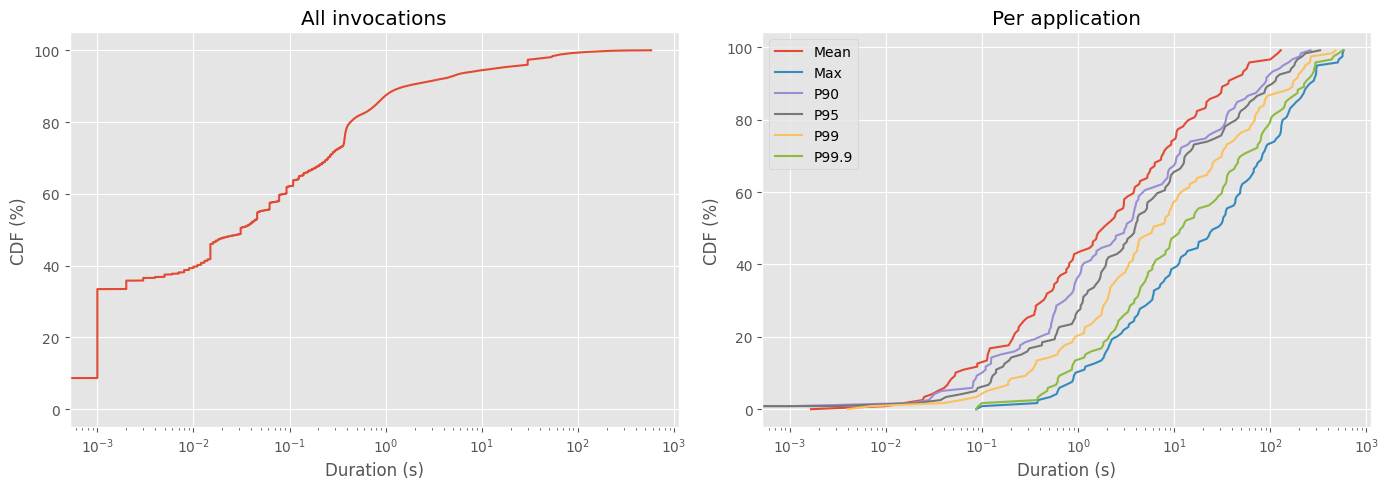

,mean,max,p90,p95,p99,p999
count,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000
mean,11.441273,82.288798,23.183940,28.569225,43.840064,64.721384
std,23.564402,127.299130,46.937815,56.626135,83.954715,110.588773
min,0.001658,0.087000,0.000000,0.000000,0.004000,0.086988
25%,0.282119,3.842000,0.538700,0.910900,1.523055,2.711269
50%,1.739000,24.862000,3.026000,3.850250,5.909250,11.434781
75%,9.794076,112.775500,17.906400,24.250950,41.827250,79.084760
max,128.122308,578.620000,261.172900,328.841750,476.014420,568.359442


In [23]:
app_duration_stats = df.groupby("app")["duration"].agg(
    mean="mean",
    max="max",
    p90=lambda s: np.percentile(s, 90),
    p95=lambda s: np.percentile(s, 95),
    p99=lambda s: np.percentile(s, 99),
    p999=lambda s: np.percentile(s, 99.9),
)

fig, (ax_all, ax_app) = plt.subplots(1, 2, figsize=(14, 5))

all_vals, all_inv = get_cdf(df, "duration")
ax_all.plot(all_vals, all_inv)
ax_all.set_title("All invocations")
ax_all.set_xlabel("Duration (s)")
ax_all.set_ylabel("CDF (%)")
ax_all.set_xscale("log")
ax_all.grid(visible=True)

for col, label in [("mean", "Mean"), ("max", "Max"), ("p90", "P90"), ("p95", "P95"), ("p99", "P99"), ("p999", "P99.9")]:
    vals, inv = get_cdf(app_duration_stats.reset_index(), col)
    ax_app.plot(vals, inv, label=label)

ax_app.set_title("Per application")
ax_app.set_xlabel("Duration (s)")
ax_app.set_ylabel("CDF (%)")
ax_app.set_xscale("log")
ax_app.legend()
ax_app.grid(visible=True)

fig.tight_layout()
plt.show()

app_duration_stats.describe()

# Inter-arrival time variability

For each `(app, func)` with at least two invocations, inter-arrival times are the gaps between consecutive `start_timestamp` values. The first plot compares CDFs of mean inter-arrival time per function and per app. The second plot shows, for each function with at least three invocations, CV = σ / μ of its inter-arrival times.

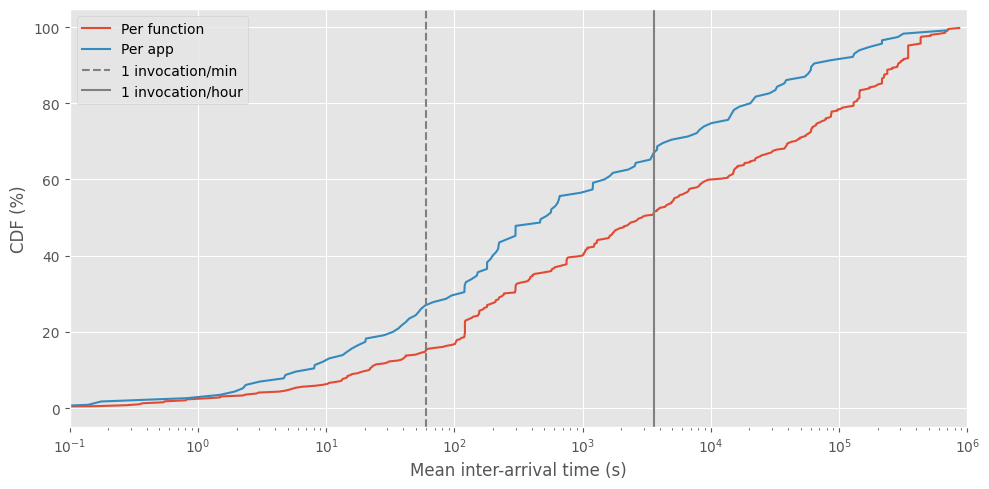

Mean IAT CDF at 1 invocation/min (60s): per function 15.6%, per app 27.8%
Mean IAT CDF at 1 invocation/hour (3600s): per function 51.8%, per app 67.8%


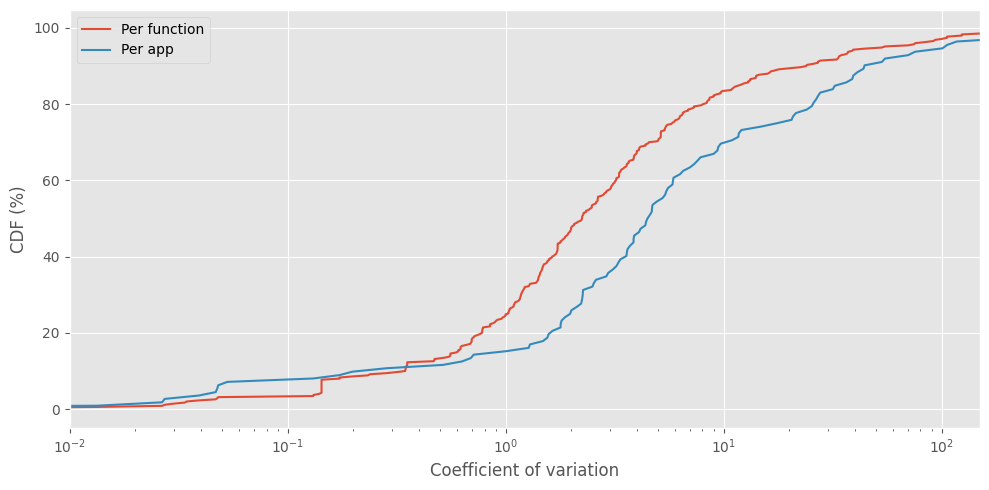

functions with mean IAT: 392
apps with mean IAT: 115
functions with CV: 350
apps with CV: 112


count    350.000000
mean      10.846099
std       30.655814
min        0.000012
25%        1.007641
50%        2.235673
75%        5.711295
max      303.554551
Name: cv, dtype: float64

In [24]:
def inter_arrival_times(timestamps: np.ndarray) -> np.ndarray:
    ts = np.sort(timestamps)
    if len(ts) < 2:
        return np.array([])
    return np.diff(ts)


def inter_arrival_cv(timestamps: np.ndarray) -> float:
    iat = inter_arrival_times(timestamps)
    if len(iat) < 2:
        return np.nan
    mean = iat.mean()
    if mean <= 0:
        return np.nan
    return float(iat.std(ddof=1) / mean)


def mean_inter_arrival(timestamps: np.ndarray) -> float:
    iat = inter_arrival_times(timestamps)
    if len(iat) == 0:
        return np.nan
    return float(iat.mean())


mean_iat_by_function = (
    df.groupby(["app", "func"], sort=False)["start_timestamp"]
    .apply(lambda ts: mean_inter_arrival(ts.values))
    .dropna()
    .rename("mean_iat")
)

mean_iat_by_app = (
    df.groupby("app", sort=False)["start_timestamp"]
    .apply(lambda ts: mean_inter_arrival(ts.values))
    .dropna()
    .rename("mean_iat")
)

cv_by_function = (
    df.groupby(["app", "func"], sort=False)["start_timestamp"]
    .apply(inter_arrival_cv)
    .dropna()
    .rename("cv")
)

cv_by_app = (
    df.groupby("app", sort=False)["start_timestamp"]
    .apply(inter_arrival_cv)
    .dropna()
    .rename("cv")
)

fig, ax = plt.subplots(figsize=(10, 5))

func_vals, func_pct = get_cdf(mean_iat_by_function.reset_index(), "mean_iat")
app_vals, app_pct = get_cdf(mean_iat_by_app.reset_index(), "mean_iat")
ax.plot(func_vals, func_pct, label="Per function")
ax.plot(app_vals, app_pct, label="Per app")
ax.axvline(60, color="gray", linestyle="--", linewidth=1.5, label="1 invocation/min")
ax.axvline(3600, color="gray", linestyle="-", linewidth=1.5, label="1 invocation/hour")
ax.set_xlim(0.1, 1000000)
ax.set_xlabel("Mean inter-arrival time (s)")
ax.set_ylabel("CDF (%)")
ax.set_xscale("log")
ax.legend()
ax.grid(visible=True)
fig.tight_layout()
plt.show()

for threshold, label in ((60, "1 invocation/min"), (3600, "1 invocation/hour")):
    func_cdf = 100 * (mean_iat_by_function <= threshold).mean()
    app_cdf = 100 * (mean_iat_by_app <= threshold).mean()
    print(f"Mean IAT CDF at {label} ({threshold}s): per function {func_cdf:.1f}%, per app {app_cdf:.1f}%")

fig, ax = plt.subplots(figsize=(10, 5))

func_cv_vals, func_cv_pct = get_cdf(cv_by_function.reset_index(), "cv")
app_cv_vals, app_cv_pct = get_cdf(cv_by_app.reset_index(), "cv")
ax.plot(func_cv_vals, func_cv_pct, label="Per function")
ax.plot(app_cv_vals, app_cv_pct, label="Per app")
ax.set_xlim(0.01, 150)
ax.set_xlabel("Coefficient of variation")
ax.set_ylabel("CDF (%)")
ax.set_xscale("log")
ax.legend()
ax.grid(visible=True)
fig.tight_layout()
plt.show()

print(f"functions with mean IAT: {len(mean_iat_by_function):,}")
print(f"apps with mean IAT: {len(mean_iat_by_app):,}")
print(f"functions with CV: {len(cv_by_function):,}")
print(f"apps with CV: {len(cv_by_app):,}")
cv_by_function.describe()

In [25]:
print(f"unique apps: {df["app"].nunique()}, unique funcs: {df["func"].nunique()}")
# df.groupby("app")["func"].count() # num of times an app is invoked
fndf = df.groupby("func")["app"].count() # num of times a function is invoked
print(fndf.sort_values())

unique apps: 119, unique funcs: 424
func
858da1f388d3bf6686711777749d40d0a5289a187fce62a8f3ad4887cb559b5a         1
e374917dc55ed7244e36f36d40cfb4d00d586f22802986acbe4c964ef506dd67         1
1e7621e92fd24b589f58b7a1cca543d9c9090ef7eec6c155414f104a61c0b5fb         1
2038eb6547255afee8270d6fe4cdde5ca4c2f9f7e5a16fab3829c11dc9bf5198         1
20cc9adaa0894d35ec28d26a065d62693ce58ef36543078dd74ef48385d443e2         1
                                                                     ...  
bd5be891d0d10fbc3c59215d5f8159ea496433bc41adba7d8d10ea21d35c3e3a    116130
4753d9ffc8a362eadfb27498581969561c0ddbec7257759dbcb9936e506aff82    124143
cc5bb2108cc7daf53f9728ad21f661a8ef9c8b36284bacfcb712e2be87eef842    142856
8ef9c2c907e9cd5fb4b5cb3bfbebca6d9a01bb1f65a0f476e3914cae25bd2aae    212755
155e47f8e7f751d0c845049456d01832013c61336a8cd85901330ac821a71534    535667
Name: app, Length: 424, dtype: int64


In [26]:
### Invocation count bins

## Each `(app, func)` is assigned to one of five quintiles by total invocation count; table below summarizes each bin.

## Invocation counts

CDF of total invocation counts over the trace window, per `(app, func)` and per app.

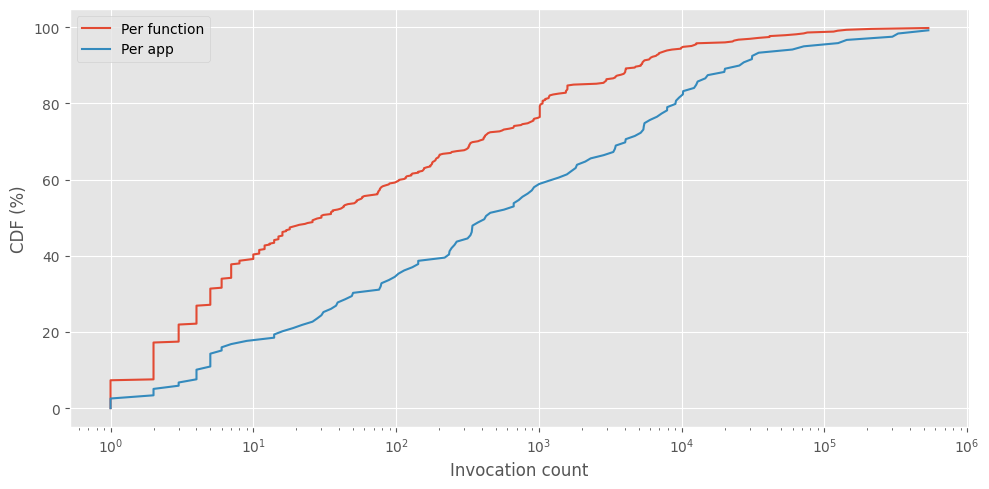

functions: 424
apps: 119


In [27]:
inv_count_by_function = (
    df.groupby(["app", "func"], sort=False).size().rename("invocation_count")
)
inv_count_by_app = df.groupby("app", sort=False).size().rename("invocation_count")

fig, ax = plt.subplots(figsize=(10, 5))

func_vals, func_pct = get_cdf(inv_count_by_function.reset_index(), "invocation_count")
app_vals, app_pct = get_cdf(inv_count_by_app.reset_index(), "invocation_count")
ax.plot(func_vals, func_pct, label="Per function")
ax.plot(app_vals, app_pct, label="Per app")
ax.set_xscale("log")
ax.set_xlabel("Invocation count")
ax.set_ylabel("CDF (%)")
ax.legend()
ax.grid(visible=True)
fig.tight_layout()
plt.show()

print(f"functions: {len(inv_count_by_function):,}")
print(f"apps: {len(inv_count_by_app):,}")

In [28]:
from forecast_eval import summarize_invocation_count_bins

per_function, bin_summary = summarize_invocation_count_bins(df, n_bins=5)
bin_summary

,bin,n_functions,inv_count_min,inv_count_max,inv_count_mean,inv_count_median,total_invocations,mean_duration,median_duration,mean_total_duration,pct_invocations,pct_functions
0,Q1,94,1,3,1.872340,2.0,176,5.299863,0.59175,9.411064,0.008885,22.169811
1,Q2,78,4,10,5.871795,5.0,458,10.937453,0.48475,58.199615,0.023120,18.396226
2,Q3,82,11,104,38.512195,30.0,3158,7.500094,0.43150,424.221793,0.159418,19.339623
3,Q4,85,105,1029,480.376471,343.0,40832,9.879576,0.25100,3535.413047,2.061232,20.047170
4,Q5,85,1062,535667,22780.317647,5172.0,1936327,13.740278,0.59600,74016.373776,97.747345,20.047170


In [29]:
df_s = df[["func", "start_timestamp"]]
df2 = df_s.loc[df_s["func"] == trace]
df_max = df_s.loc[df_s["func"] == t_max]

# date from Azure GH
df2["start_timestamp"] = pd.to_datetime(df2["start_timestamp"], origin="2021-01-31", unit="s")
df2 = df2.set_index("start_timestamp")

dfc = df2.resample("5min").count()
dfc = dfc.reset_index()
print(dfc)

        start_timestamp  func
0   2021-01-31 00:00:00     8
1   2021-01-31 00:05:00     8
2   2021-01-31 00:10:00     8
3   2021-01-31 00:15:00     8
4   2021-01-31 00:20:00     8
..                  ...   ...
624 2021-02-02 04:00:00    10
625 2021-02-02 04:05:00    14
626 2021-02-02 04:10:00    12
627 2021-02-02 04:15:00    11
628 2021-02-02 04:20:00     8

[629 rows x 2 columns]


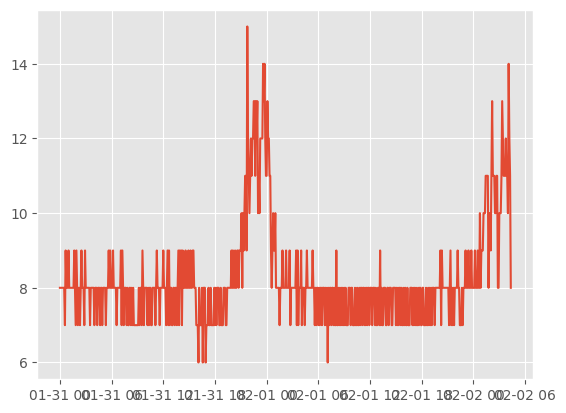

In [30]:
plt.plot(dfc['start_timestamp'], dfc['func'])

In [31]:
df_max["start_timestamp"] = pd.to_datetime(df_max["start_timestamp"], unit="s")
df_max = df_max.set_index("start_timestamp")

dfc_max = df_max.resample("5min").count()
dfc_max = df_max.reset_index()
print(dfc_max)

                     start_timestamp  \
0      1970-01-01 01:47:09.368362011   
1      1970-01-01 01:47:10.616194014   
2      1970-01-01 01:47:10.960727900   
3      1970-01-01 01:47:12.308424992   
4      1970-01-01 01:47:12.589627909   
...                              ...   
535662 1970-01-14 23:59:56.700016903   
535663 1970-01-14 23:59:58.190409111   
535664 1970-01-14 23:59:58.560518908   
535665 1970-01-14 23:59:58.627381968   
535666 1970-01-14 23:59:59.693463969   

                                                     func  
0       155e47f8e7f751d0c845049456d01832013c61336a8cd8...  
1       155e47f8e7f751d0c845049456d01832013c61336a8cd8...  
2       155e47f8e7f751d0c845049456d01832013c61336a8cd8...  
3       155e47f8e7f751d0c845049456d01832013c61336a8cd8...  
4       155e47f8e7f751d0c845049456d01832013c61336a8cd8...  
...                                                   ...  
535662  155e47f8e7f751d0c845049456d01832013c61336a8cd8...  
535663  155e47f8e7f751d0c845049456d0183

## Forecast evaluation

Holdout evaluation with MASE and RMSSE via `forecast_eval.py` (baselines, ARIMA, Prophet). Values below 1 beat the in-sample seasonal naive benchmark. Exploratory Prophet/ARIMA cells below use the same trace but are not part of the holdout runner.

In [32]:
from forecast_eval import (
    build_invocation_series,
    default_holdout_forecasters,
    evaluate_trace,
    summarize_results,
    temporal_split,
    plot_holdout,
    evaluate_series,
    top_function_keys,
    SeasonalNaiveForecaster,
    _default_season_length,
)

eval_freq = "1min"

# Top functions by invocation volume (includes t_max workload)
top_keys = top_function_keys(df, n=5)
print(f"Evaluating {len(top_keys)} functions")

forecasters = default_holdout_forecasters(freq=eval_freq)
results = evaluate_trace(
    df,
    forecasters,
    freq=eval_freq,
    keys=top_keys,
)

summarize_results(results)

Evaluating 5 functions


12:58:41 - cmdstanpy - INFO - Chain [1] start processing
12:58:42 - cmdstanpy - INFO - Chain [1] done processing
12:58:48 - cmdstanpy - INFO - Chain [1] start processing
12:58:49 - cmdstanpy - INFO - Chain [1] done processing
12:59:02 - cmdstanpy - INFO - Chain [1] start processing
12:59:03 - cmdstanpy - INFO - Chain [1] done processing
12:59:11 - cmdstanpy - INFO - Chain [1] start processing
12:59:13 - cmdstanpy - INFO - Chain [1] done processing
12:59:36 - cmdstanpy - INFO - Chain [1] start processing
12:59:37 - cmdstanpy - INFO - Chain [1] done processing


,model,mase_mean,mase_median,rmsse_mean,rmsse_median,n_functions
1,auto_arima_1_1_1,0.498790,0.498790,1.219080,1.219080,1
3,auto_arima_5_1_0,0.824093,0.824093,1.234661,1.234661,1
7,seasonal_naive,1.987164,1.345836,1.591049,1.643846,5
6,prophet,2.651494,0.944716,1.552907,1.219080,5
0,auto_arima_0_1_1,2.910656,2.910656,1.817250,1.817250,1
4,moving_average_w12,4.733824,0.824093,2.187866,1.234661,5
5,naive,5.130416,0.824093,2.306779,1.234661,5
2,auto_arima_3_1_2,10.796069,10.796069,3.629620,3.629620,2


### h-step-ahead cross-validation

Rolling-origin CV: at each origin, train on past data, forecast **10 minutes** ahead (`h=10` at `1min` freq), score with MASE/RMSSE. Uses **10 evenly spaced folds** across the trace. Prophet excluded here for runtime.

In [33]:
import time

from forecast_eval import evaluate_trace_cv, summarize_results, default_forecasters

cv_h = 10
cv_max_folds = 10
cv_forecasters = default_forecasters(freq=eval_freq, include_prophet=False)

t0 = time.perf_counter()
cv_results = evaluate_trace_cv(
    df,
    cv_forecasters,
    h=cv_h,
    freq=eval_freq,
    keys=top_keys,
    max_folds=cv_max_folds,
)
cv_elapsed = time.perf_counter() - t0

print(f"CV finished in {cv_elapsed:.1f}s ({cv_elapsed / 60:.1f} min)")
summarize_results(cv_results)

/Users/jori/Projects/thesis/thesis-env/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/jori/Projects/thesis/thesis-env/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/jori/Projects/thesis/thesis-env/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/jori/Projects/thesis/thesis-env/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters

CV finished in 23.7s (0.4 min)


,model,mase_mean,mase_median,rmsse_mean,rmsse_median,n_functions,n_folds_mean
2,naive,0.350786,0.289362,0.225712,0.232564,5,10.0
0,arima_2_1_2,0.354283,0.304513,0.221336,0.233610,5,10.0
1,moving_average_w12,0.433210,0.520176,0.270841,0.248931,5,10.0
3,seasonal_naive,4.404936,1.191950,1.314783,0.836758,5,10.0


In [34]:
cv_results

,app,func,model,freq,h,step,n_folds,n_valid_folds,mase,rmsse
0,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,naive,1min,10,10,10,10,0.289362,0.248755
1,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,seasonal_naive,1min,10,10,10,10,0.664941,0.593426
2,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,moving_average_w12,1min,10,10,10,10,0.297602,0.248931
3,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,arima_2_1_2,1min,10,10,10,10,0.304513,0.256993
4,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...,8ef9c2c907e9cd5fb4b5cb3bfbebca6d9a01bb1f65a0f4...,naive,1min,10,10,10,10,0.584043,0.232564
5,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...,8ef9c2c907e9cd5fb4b5cb3bfbebca6d9a01bb1f65a0f4...,seasonal_naive,1min,10,10,10,10,15.355938,2.600683
6,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...,8ef9c2c907e9cd5fb4b5cb3bfbebca6d9a01bb1f65a0f4...,moving_average_w12,1min,10,10,10,10,0.584043,0.232564
7,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...,8ef9c2c907e9cd5fb4b5cb3bfbebca6d9a01bb1f65a0f4...,arima_2_1_2,1min,10,10,10,10,0.595323,0.233610
8,7958f89676bf3653f72cda8f38f6b3c0574dcae5169824...,cc5bb2108cc7daf53f9728ad21f661a8ef9c8b36284bac...,naive,1min,10,10,10,10,0.509655,0.362548
9,7958f89676bf3653f72cda8f38f6b3c0574dcae5169824...,cc5bb2108cc7daf53f9728ad21f661a8ef9c8b36284bac...,seasonal_naive,1min,10,10,10,10,1.191950,0.718790


In [35]:
results

,app,func,model,freq,n_train,n_test,mase,rmsse
0,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,naive,1min,16042,4011,0.495362,0.720505
1,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,seasonal_naive,1min,16042,4011,0.675443,0.806714
2,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,moving_average_w12,1min,16042,4011,0.495362,0.720505
3,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,auto_arima_3_1_2,1min,16042,4011,0.552151,0.681935
4,a594f92f84072b4cd031fe5283d1781a6e98f430696dec...,155e47f8e7f751d0c845049456d01832013c61336a8cd8...,prophet,1min,16042,4011,0.505337,0.718818
5,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...,8ef9c2c907e9cd5fb4b5cb3bfbebca6d9a01bb1f65a0f4...,naive,1min,8426,2107,2.910656,1.817250
6,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...,8ef9c2c907e9cd5fb4b5cb3bfbebca6d9a01bb1f65a0f4...,seasonal_naive,1min,8426,2107,2.910656,1.817250
7,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...,8ef9c2c907e9cd5fb4b5cb3bfbebca6d9a01bb1f65a0f4...,moving_average_w12,1min,8426,2107,2.910656,1.817250
8,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...,8ef9c2c907e9cd5fb4b5cb3bfbebca6d9a01bb1f65a0f4...,auto_arima_0_1_1,1min,8426,2107,2.910656,1.817250
9,a9644719e5d173a27e098cffdd5e9227ba9c4a325d082c...,8ef9c2c907e9cd5fb4b5cb3bfbebca6d9a01bb1f65a0f4...,prophet,1min,8426,2107,2.910656,1.817250


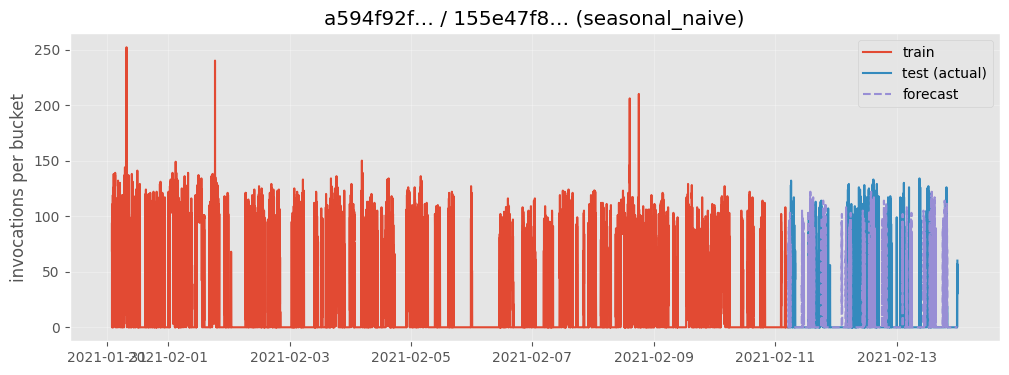

In [36]:
# Holdout plot for the busiest function
if not results.empty:
    app, func = top_keys[0]
    series = build_invocation_series(df, freq=eval_freq)[app, func]
    split = temporal_split(series)
    model = SeasonalNaiveForecaster(freq=eval_freq)
    ev = evaluate_series(
        split.train,
        split.test,
        model,
        season_length=_default_season_length(eval_freq),
    )
    plot_holdout(split, ev["y_pred"], title=f"{app[:8]}… / {func[:8]}… ({ev['model']})")
    plt.show()